<a href="https://colab.research.google.com/github/ssabouni/DentalFaultDetection/blob/main/model_training_binary.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Preprocessing

In [ ]:
import os
import json
import cv2
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from collections import Counter
import numpy as np

from google.colab import drive
drive.mount('/content/drive')

# Define paths for train, valid, and test datasets
base_dir = "/content/drive/MyDrive/dental-project/data"
train_image_dir = os.path.join(base_dir, "train")
valid_image_dir = os.path.join(base_dir, "valid")
subsets = ["train", "valid", "test"]

# Global dictionaries
class_counts = Counter()
categories = {}  # To store category names
annotations = {}

# Function to process datasets
def process_dataset(subset):
    global categories  # Ensure global access
    image_dir = os.path.join(base_dir, subset)
    annotation_file = os.path.join(image_dir, "_annotations.coco.json")

    if not os.path.exists(annotation_file):
        print(f"⚠️ Annotation file missing: {annotation_file}")
        return

    with open(annotation_file, 'r') as f:
        coco_data = json.load(f)

    images = {img['id']: img for img in coco_data['images']}
    annotations = coco_data['annotations']

    # Initialize categories only once
    if not categories:
        categories = {cat['id']: cat['name'] for cat in coco_data['categories']}

    # Count bounding boxes per class
    for ann in annotations:
        class_counts[ann['category_id']] += 1

    print(f"📂 {subset.upper()} SET: {len(images)} images, {len(annotations)} annotations.")

# Run for all subsets
for subset in subsets:
    process_dataset(subset)

# Print bounding box count per class
print("\nBounding Box Count Per Class:")
for class_id, count in class_counts.items():
    class_name = categories.get(class_id, "Unknown")
    print(f"{class_name}: {count}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📂 TRAIN SET: 315 images, 768 annotations.
📂 VALID SET: 21 images, 71 annotations.
📂 TEST SET: 21 images, 56 annotations.

Bounding Box Count Per Class:
insufficient light body: 424
uneven finish line: 274
void: 105
non-continuous finish line: 92


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
import numpy as np
import json
import os
import matplotlib.pyplot as plt
from tensorflow.keras.utils import Sequence
import cv2

# Set base directory
base_dir = "/content/drive/MyDrive/dental-project/data"

# Define paths for images and annotations
train_image_dir = os.path.join(base_dir, "train")
valid_image_dir = os.path.join(base_dir, "valid")

train_annotation_file = os.path.join(train_image_dir, "_annotations.coco.json")
val_annotation_file = os.path.join(valid_image_dir, "_annotations.coco.json")

# Load annotations
def load_annotations(annotation_file):
    with open(annotation_file, 'r') as f:
        return json.load(f)

train_annotations = load_annotations(train_annotation_file)
val_annotations = load_annotations(val_annotation_file)

# converts all original fault types into one single class called fault
def convert_annotations_to_binary(coco_data):
    for ann in coco_data["annotations"]:
        ann["category_id"] = 1   # every annotated box = fault
    coco_data["categories"] = [
        {"id": 1, "name": "fault"}
    ]
    return coco_data

train_annotations = convert_annotations_to_binary(train_annotations)
val_annotations = convert_annotations_to_binary(val_annotations)


# Data Generator Class
class ObjectDetectionDataGenerator(Sequence):
    def __init__(self, annotations, image_dir, batch_size=32, shuffle=True, max_objects=8):
        self.image_dir = image_dir
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.max_objects = max_objects

        self.img_id_to_filename = {img['id']: img['file_name'] for img in annotations['images']}
        self.img_id_to_size = {img['id']: (img['width'], img['height']) for img in annotations['images']}
        self.annotations_by_image = {}

        for ann in annotations['annotations']:
            image_id = ann['image_id']
            if image_id not in self.annotations_by_image:
                self.annotations_by_image[image_id] = []
            self.annotations_by_image[image_id].append(ann)

        self.image_ids = list(self.annotations_by_image.keys())
        if self.shuffle:
            np.random.shuffle(self.image_ids)

    def __getitem__(self, index):
        batch_ids = self.image_ids[index * self.batch_size:(index + 1) * self.batch_size]
        images, boxes, classes = [], [], []

        for image_id in batch_ids:
            image_path = os.path.join(self.image_dir, self.img_id_to_filename[image_id])
            image = cv2.imread(image_path)

            if image is None:
                print(f"Warning: Skipping missing image {image_path}")
                continue

            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            image = image.astype(np.float32)
            images.append(image)

            anns = self.annotations_by_image[image_id]

            b = np.array([ann['bbox'] for ann in anns], dtype=np.float32)
            c = np.ones(len(anns), dtype=np.int32)

            # Normalize bbox from pixels to 0-1 using original image size
            img_w, img_h = self.img_id_to_size[image_id]
            if len(b) > 0:
                b[:, 0] = b[:, 0] / img_w   # x
                b[:, 1] = b[:, 1] / img_h   # y
                b[:, 2] = b[:, 2] / img_w   # width
                b[:, 3] = b[:, 3] / img_h   # height

            if len(b) > self.max_objects:
                b = b[:self.max_objects]
                c = c[:self.max_objects]

            b = np.pad(
                b,
                ((0, max(0, self.max_objects - len(b))), (0, 0)),
                mode='constant',
                constant_values=0
            )
            c = np.pad(
                c,
                (0, max(0, self.max_objects - len(c))),
                mode='constant',
                constant_values=0
            )

            boxes.append(b)
            classes.append(c)

        return np.array(images), (np.array(boxes), np.array(classes))

    def __len__(self):
        return int(np.ceil(len(self.image_ids) / self.batch_size))

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.image_ids)


In [ ]:
# Create training and validation generators
train_generator = ObjectDetectionDataGenerator(
    train_annotations,
    train_image_dir,
    batch_size=8,
    max_objects=8
)

val_generator = ObjectDetectionDataGenerator(
    val_annotations,
    valid_image_dir,
    batch_size=8,
    max_objects=8
)

# Use dynamically determined max_objects
max_objects = train_generator.max_objects

from tensorflow.keras.applications import MobileNetV2

from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

def build_model(input_shape=(640, 640, 3), max_objects=8):
    inputs = tf.keras.Input(shape=input_shape)

    # 1. Preprocess: This converts [0, 255] inputs to [-1, 1]
    # Use a lambda layer to call the official mobilenet_v2 preprocessor
    x = tf.keras.layers.Lambda(preprocess_input)(inputs)

    # 2. Backbone
    base_model = MobileNetV2(input_shape=input_shape, include_top=False, weights='imagenet')
    base_model.trainable = False
    x = base_model(x, training=False)

    x = layers.GlobalAveragePooling2D()(x)

    # 3. Heads
    x = layers.Dense(256, activation='relu')(x)
    bbox_output = layers.Dense(4 * max_objects, activation='sigmoid')(x)
    bbox_output = layers.Reshape((max_objects, 4), name='bbox')(bbox_output)

    num_classes = 1
    class_output = layers.Dense(max_objects * num_classes, activation='sigmoid')(x)
    class_output = layers.Reshape((max_objects, num_classes), name='class')(class_output)

    model = models.Model(inputs=inputs, outputs=[bbox_output, class_output])
    return model

model = build_model()
model.summary()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4), # Lower LR for transfer learning!
    loss={
        'bbox': 'mse',
        'class': 'binary_crossentropy'
    },
    loss_weights={
        'bbox': 10.0,  # BBox loss is usually smaller; scale it up to force learning
        'class': 1.0
    },
    metrics={
        'bbox': ['mae'],
        'class': ['accuracy']
    }
)


/tmp/ipykernel_87857/1195225440.py:31: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(input_shape=input_shape, include_top=False, weights='imagenet')


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 640, 640,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 640, 640,  │          0 │ input_layer[0][0] │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_2… │ (None, 20, 20,    │  2,257,984 │ lambda[0][0]      │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    327,936 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      8,224 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 8)         │      2,056 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bbox (Reshape)      │ (None, 8, 4)      │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ class (Reshape)     │ (None, 8, 1)      │          0 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,596,200 (9.90 MB)

 Trainable params: 338,216 (1.29 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# Check one batch to check normalising worked

images, (true_boxes, true_classes) = train_generator[0]
print(true_boxes[0])
print(true_boxes.min(), true_boxes.max())

[[0.353125   0.571875   0.11328125 0.07265625]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]]
0.0 0.8515625


Starting training...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - bbox_loss: 0.1535 - bbox_mae: 0.3562 - class_accuracy: 0.5729 - class_loss: 0.6707 - loss: 2.2078
Epoch 1: val_loss improved from None to 0.98085, saving model to /content/drive/MyDrive/dental-project/models/dental_fault_best.h5



Epoch 1: finished saving model to /content/drive/MyDrive/dental-project/models/dental_fault_best.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 139s 4s/step - bbox_loss: 0.1127 - bbox_mae: 0.3018 - class_accuracy: 0.6824 - class_loss: 0.5909 - loss: 1.7196 - val_bbox_loss: 0.0518 - val_bbox_mae: 0.1955 - val_class_accuracy: 0.7560 - val_class_loss: 0.4614 - val_loss: 0.9808
Epoch 2/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - bbox_loss: 0.0406 - bbox_mae: 0.1725 - class_accuracy: 0.8295 - class_loss: 0.4168 - loss: 0.8234
Epoch 2: val_loss improved from 0.98085 to 0.70703, saving model to /content/drive/MyDrive/dental-project/models/dental_fault_best.h5



Epoch 2: finished saving model to /content/drive/MyDrive/dental-project/models/dental_fault_best.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 131s 3s/step - bbox_loss: 0.0337 - bbox_mae: 0.1508 - class_accuracy: 0.8389 - class_loss: 0.3962 - loss: 0.7330 - val_bbox_loss: 0.0293 - val_bbox_mae: 0.1202 - val_class_accuracy: 0.8393 - val_class_loss: 0.4109 - val_loss: 0.7070
Epoch 3/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - bbox_loss: 0.0214 - bbox_mae: 0.1085 - class_accuracy: 0.8561 - class_loss: 0.3266 - loss: 0.5410
Epoch 3: val_loss improved from 0.70703 to 0.67072, saving model to /content/drive/MyDrive/dental-project/models/dental_fault_best.h5



Epoch 3: finished saving model to /content/drive/MyDrive/dental-project/models/dental_fault_best.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 119s 3s/step - bbox_loss: 0.0218 - bbox_mae: 0.1054 - class_accuracy: 0.8407 - class_loss: 0.3550 - loss: 0.5740 - val_bbox_loss: 0.0275 - val_bbox_mae: 0.1030 - val_class_accuracy: 0.8274 - val_class_loss: 0.4225 - val_loss: 0.6707
Epoch 4/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - bbox_loss: 0.0209 - bbox_mae: 0.0977 - class_accuracy: 0.8325 - class_loss: 0.3638 - loss: 0.5735
Epoch 4: val_loss improved from 0.67072 to 0.65976, saving model to /content/drive/MyDrive/dental-project/models/dental_fault_best.h5



Epoch 4: finished saving model to /content/drive/MyDrive/dental-project/models/dental_fault_best.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 121s 4s/step - bbox_loss: 0.0195 - bbox_mae: 0.0930 - class_accuracy: 0.8454 - class_loss: 0.3441 - loss: 0.5389 - val_bbox_loss: 0.0234 - val_bbox_mae: 0.0969 - val_class_accuracy: 0.8274 - val_class_loss: 0.3881 - val_loss: 0.6598
Epoch 5/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - bbox_loss: 0.0177 - bbox_mae: 0.0855 - class_accuracy: 0.8688 - class_loss: 0.3032 - loss: 0.4803
Epoch 5: val_loss did not improve from 0.65976
34/34 ━━━━━━━━━━━━━━━━━━━━ 112s 3s/step - bbox_loss: 0.0186 - bbox_mae: 0.0869 - class_accuracy: 0.8532 - class_loss: 0.3356 - loss: 0.5204 - val_bbox_loss: 0.0251 - val_bbox_mae: 0.0944 - val_class_accuracy: 0.7857 - val_class_loss: 0.3933 - val_loss: 0.6625
Epoch 6/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - bbox_loss: 0.0185 - bbox_mae: 0.0845 - class_accuracy: 0.8595 - class_loss: 0.3282 - loss: 0.5134
Epoch 6: val_loss improved from 0.


Epoch 6: finished saving model to /content/drive/MyDrive/dental-project/models/dental_fault_best.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 117s 3s/step - bbox_loss: 0.0180 - bbox_mae: 0.0838 - class_accuracy: 0.8620 - class_loss: 0.3267 - loss: 0.5070 - val_bbox_loss: 0.0246 - val_bbox_mae: 0.0920 - val_class_accuracy: 0.8095 - val_class_loss: 0.4006 - val_loss: 0.6552
Epoch 7/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - bbox_loss: 0.0178 - bbox_mae: 0.0820 - class_accuracy: 0.8575 - class_loss: 0.3191 - loss: 0.4973
Epoch 7: val_loss did not improve from 0.65518
34/34 ━━━━━━━━━━━━━━━━━━━━ 112s 3s/step - bbox_loss: 0.0175 - bbox_mae: 0.0814 - class_accuracy: 0.8630 - class_loss: 0.3193 - loss: 0.4954 - val_bbox_loss: 0.0240 - val_bbox_mae: 0.0904 - val_class_accuracy: 0.7857 - val_class_loss: 0.4473 - val_loss: 0.6623
Epoch 8/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - bbox_loss: 0.0158 - bbox_mae: 0.0766 - class_accuracy: 0.8865 - class_loss: 0.2863 - loss: 0.4435
Epoch 8: val_loss improved from 0.


Epoch 8: finished saving model to /content/drive/MyDrive/dental-project/models/dental_fault_best.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 119s 4s/step - bbox_loss: 0.0173 - bbox_mae: 0.0787 - class_accuracy: 0.8685 - class_loss: 0.3136 - loss: 0.4849 - val_bbox_loss: 0.0234 - val_bbox_mae: 0.0885 - val_class_accuracy: 0.8155 - val_class_loss: 0.3973 - val_loss: 0.6347
Epoch 9/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - bbox_loss: 0.0169 - bbox_mae: 0.0780 - class_accuracy: 0.8657 - class_loss: 0.3035 - loss: 0.4730
Epoch 9: val_loss did not improve from 0.63475
34/34 ━━━━━━━━━━━━━━━━━━━━ 114s 3s/step - bbox_loss: 0.0170 - bbox_mae: 0.0785 - class_accuracy: 0.8620 - class_loss: 0.3088 - loss: 0.4795 - val_bbox_loss: 0.0235 - val_bbox_mae: 0.0898 - val_class_accuracy: 0.7976 - val_class_loss: 0.4152 - val_loss: 0.6615
Epoch 10/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - bbox_loss: 0.0174 - bbox_mae: 0.0782 - class_accuracy: 0.8748 - class_loss: 0.3024 - loss: 0.4746
Epoch 10: val_loss did not improv

Model saved to /content/drive/MyDrive/dental-project/models/dental_fault_detector.h5


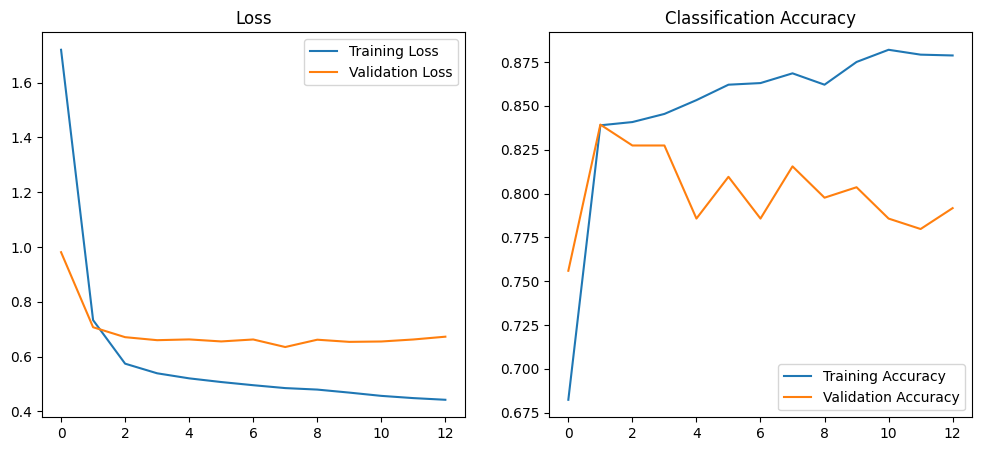

In [ ]:
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# 1. Define your plotting function FIRST (so it's ready to use)
def plot_history(history):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    # Ensure these key names match your model.compile metrics
    plt.plot(history.history['class_accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_class_accuracy'], label='Validation Accuracy')
    plt.title('Classification Accuracy')
    plt.legend()
    plt.show()

# 2. Define your callbacks
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),
    # Optional but recommended to prevent losing work on disconnect
    tf.keras.callbacks.ModelCheckpoint(
        filepath="/content/drive/MyDrive/dental-project/models/dental_fault_best.h5",
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

# 3. Train the model ONCE
print("Starting training...")
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    callbacks=callbacks,
    verbose=1
)

# 4. Save the model (the final state)
model_save_path = "/content/drive/MyDrive/dental-project/models/dental_fault_detector.h5"
os.makedirs(os.path.dirname(model_save_path), exist_ok=True)
model.save(model_save_path)
print(f"Model saved to {model_save_path}")

# 5. Plot the history
plot_history(history)

In [ ]:
# Test Model

test_results = model.evaluate(val_generator, verbose=1)

print("Raw test_results =", test_results)

print(f"Final Val Total Loss: {test_results[0]:.2f}")
print(f"Final Val BBox MSE: {test_results[1]:.2f}")
print(f"Final Val BBox MAE: {test_results[2]:.2f}px")
print(f"Final Val Class Loss: {test_results[3]:.2f}")
print(f"Final Val Class Acc: {test_results[4]:.1%}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 12s 3s/step - bbox_loss: 0.0230 - bbox_mae: 0.0885 - class_accuracy: 0.8155 - class_loss: 0.3840 - loss: 0.6347
Raw test_results = [0.6347482800483704, 0.022984787821769714, 0.3840327262878418, 0.08854858577251434, 0.8154761791229248]
Final Val Total Loss: 0.63
Final Val BBox MSE: 0.02
Final Val BBox MAE: 0.38px
Final Val Class Loss: 0.09
Final Val Class Acc: 81.5%


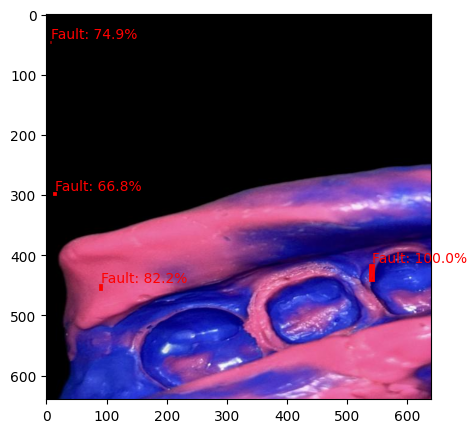

In [ ]:
# Test single image (pick one from valid/)
import cv2
import matplotlib.pyplot as plt

img_path = "/content/drive/MyDrive/dental-project/data/valid/014-B_jpeg.rf.0219df36ef17bf89b0cb80241cf1c9b7 3.jpg"
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img, (640, 640)) / 255.0
img_resized = np.expand_dims(img_resized, 0)

boxes, classes = model.predict(img_resized, verbose=0)

# Show predictions (conf > 0.5)
plt.figure(figsize=(10, 5))
plt.imshow(img)
for i in range(8):
    conf = classes[0, i, 0]
    if conf > 0.5:
        x, y, w, h = boxes[0, i] * 640  # Scale back to original
        rect = plt.Rectangle((x-w/2, y-h/2), w, h, fill=False, color='red', linewidth=2)
        plt.gca().add_patch(rect)
        plt.text(x, y-h/2-5, f'Fault: {conf:.1%}', color='red')
plt.show()


In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score


#define test data

test_image_dir = os.path.join(base_dir, "test")
test_annotation_file = os.path.join(test_image_dir, "_annotations.coco.json")

test_annotations = load_annotations(test_annotation_file)

test_generator = ObjectDetectionDataGenerator(test_annotations, test_image_dir, max_objects=8)


# Function to compute IoU (Intersection over Union)
def compute_iou(box1, box2):
    """ Compute Intersection over Union (IoU) between two bounding boxes. """
    x1, y1, w1, h1 = box1
    x2, y2, w2, h2 = box2

    # Convert to (x_min, y_min, x_max, y_max)
    box1 = [x1, y1, x1 + w1, y1 + h1]
    box2 = [x2, y2, x2 + w2, y2 + h2]

    # Compute intersection
    xi1 = max(box1[0], box2[0])
    yi1 = max(box1[1], box2[1])
    xi2 = min(box1[2], box2[2])
    yi2 = min(box1[3], box2[3])
    inter_area = max(0, xi2 - xi1) * max(0, yi2 - yi1)

    # Compute union
    box1_area = w1 * h1
    box2_area = w2 * h2
    union_area = box1_area + box2_area - inter_area

    return inter_area / union_area if union_area > 0 else 0

# Load model if not already in memory
model = tf.keras.models.load_model("../models/dental_fault_detector.h5")  # Replace with actual model path

# Run model on test dataset
test_images, test_labels = next(iter(test_generator))  # Load test batch, (Only one batch, change to loop over all test dataset if more than 32 images)
predictions = model.predict(test_images)

# Extract predicted bounding boxes and class labels
pred_bboxes, pred_classes = predictions  # Shape: (batch_size, max_objects, 4) & (batch_size, max_objects, num_classes)
true_bboxes, true_classes = test_labels   # Ground truth

# Convert softmax class outputs to actual labels
pred_classes = np.argmax(pred_classes, axis=-1)  # (batch_size, max_objects)

# Compute bounding box regression error (MAE)
mae_bbox = np.mean(np.abs(pred_bboxes - true_bboxes))

# Compute IoU for bounding box predictions
ious = []
for i in range(len(test_images)):  # Loop over batch
    for j in range(pred_bboxes.shape[1]):  # Loop over objects
        iou = compute_iou(pred_bboxes[i][j], true_bboxes[i][j])
        ious.append(iou)

mean_iou = np.mean(ious)

# Compute classification accuracy
true_classes_flat = true_classes.flatten()
pred_classes_flat = pred_classes.flatten()

accuracy = accuracy_score(true_classes_flat, pred_classes_flat)
f1 = f1_score(true_classes_flat, pred_classes_flat, average="weighted", labels=np.unique(true_classes_flat))

# Print Evaluation Metrics
print(f"Bounding Box Regression MAE: {mae_bbox:.4f}")
print(f"Mean IoU: {mean_iou:.4f}")
print(f"Classification Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")

# Visualise Predictions
def plot_predictions(images, true_bboxes, pred_bboxes, true_classes, pred_classes, num_samples=5):
    fig, axes = plt.subplots(1, num_samples, figsize=(15, 5))

    for i in range(num_samples):
        ax = axes[i]
        ax.imshow(images[i].astype("uint8"))

        # True Bounding Box (Green)
        for j in range(true_bboxes.shape[1]):  # Loop over objects
            x, y, w, h = true_bboxes[i][j]
            rect = plt.Rectangle((x, y), w, h, edgecolor="green", linewidth=2, fill=False)
            ax.add_patch(rect)
            ax.text(x, y - 5, f"True: {true_classes[i][j]}", color="green", fontsize=8)

        # Predicted Bounding Box (Red)
        for j in range(pred_bboxes.shape[1]):
            x, y, w, h = pred_bboxes[i][j]
            rect = plt.Rectangle((x, y), w, h, edgecolor="red", linewidth=2, fill=False)
            ax.add_patch(rect)
            ax.text(x, y - 15, f"Pred: {pred_classes[i][j]}", color="red", fontsize=8)

        ax.axis("off")

    plt.show()

# Display some predictions
plot_predictions(test_images, true_bboxes, pred_bboxes, true_classes, pred_classes)


FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '../models/dental_fault_detector.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [ ]:
import json
import numpy as np
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

# Load ground truth annotations (COCO format)
gt_annotations_path = val_annotation_file  # Path to validation annotations JSON
coco_gt = COCO(gt_annotations_path)

print(f"COCO Categories: {coco_gt.getCatIds()}")
pred_category_ids = {p["category_id"] for p in predictions}
print(f"Predicted Categories: {pred_category_ids}")
print("COCO Category Mapping:", coco_gt.cats)


# Collect predictions in COCO format
predictions = []

for batch_images, (batch_boxes, batch_classes) in val_generator:
    pred_boxes, pred_classes_raw = model.predict(batch_images)

    # Convert class probabilities to actual class IDs
    pred_classes = np.argmax(pred_classes_raw, axis=-1)  # Shape: (batch_size, max_objects)
    scores = np.max(pred_classes_raw, axis=-1)  # Get the highest probability per object

    # Iterate over batch
    for i, image_id in enumerate(batch_images):  # ✅ Ensure correct image tracking
        for j, box in enumerate(pred_boxes[i]):
            x, y, w, h = box  # COCO expects [x, y, width, height]

            pred_class = int(pred_classes[i][j])
            pred_score = float(scores[i][j])

            if pred_class == 1:   # keep only predicted fault boxes
                predictions.append({
                    "image_id": int(val_generator.image_ids[i]),
                    "category_id": 1,
                    "bbox": [float(x), float(y), float(w), float(h)],
                    "score": pred_score
                })


# Save predictions as a JSON file
predictions_path = "predictions.json"
with open(predictions_path, "w") as f:
    json.dump(predictions, f)

# Load predictions into COCO API
coco_dt = coco_gt.loadRes(predictions_path)

# Initialize COCO evaluation
coco_eval = COCOeval(coco_gt, coco_dt, "bbox")
coco_eval.evaluate()
coco_eval.accumulate()
coco_eval.summarize()

# Extract mAP@50 and mAP@75
mAP_50 = coco_eval.stats[1]  # AP@IoU=0.50
mAP_75 = coco_eval.stats[2]  # AP@IoU=0.75

print(f"mAP@50: {mAP_50:.4f}")
print(f"mAP@75: {mAP_75:.4f}")


coco_eval.params.iouThrs = np.linspace(0.1, 0.5, 5)  # Instead of 0.5 to 0.95

In [ ]:
print(f"Shape of pred_classes[{i}][{j}]:", pred_classes[i][j].shape)
print(f"Value of pred_classes[{i}][{j}]:", pred_classes[i][j])


In [ ]:
import numpy as np

def compute_iou(box1, box2):
    """Compute IoU between two bounding boxes"""
    x1, y1, w1, h1 = box1
    x2, y2, w2, h2 = box2

    # Convert width/height to x2/y2
    x1b, y1b, x2b, y2b = x1, y1, x1 + w1, y1 + h1
    x1g, y1g, x2g, y2g = x2, y2, x2 + w2, y2 + h2

    # Compute intersection
    xi1, yi1, xi2, yi2 = max(x1b, x1g), max(y1b, y1g), min(x2b, x2g), min(y2b, y2g)
    inter_area = max(0, xi2 - xi1) * max(0, yi2 - yi1)

    # Compute union
    box1_area = (x2b - x1b) * (y2b - y1b)
    box2_area = (x2g - x1g) * (y2g - y1g)
    union_area = box1_area + box2_area - inter_area

    return inter_area / union_area if union_area > 0 else 0


In [ ]:
# Simulated predictions (you would replace this with actual model predictions)
predicted_annotations = [...]  # List of predicted bounding boxes with 'category_id'

iou_per_class = {cat_id: [] for cat_id in class_counts.keys()}

for ann in annotations:
    true_box = ann['bbox']
    category_id = ann['category_id']

    # Find the best-matching predicted box (dummy example, replace with model output)
    best_iou = 0
    for pred in predicted_annotations:
        if pred['category_id'] == category_id:
            iou = compute_iou(true_box, pred['bbox'])
            best_iou = max(best_iou, iou)

    iou_per_class[category_id].append(best_iou)

# Compute mean IoU per class
print("\nMean IoU Per Class:")
for class_id, ious in iou_per_class.items():
    mean_iou = np.mean(ious) if ious else 0
    print(f"{categories[class_id]}: Mean IoU = {mean_iou:.4f}")


In [ ]:
coco_dt = coco_gt.loadRes(predictions_path)
print(f"Loaded {len(coco_dt.anns)} predictions")


In [ ]:
coco_eval.params.iouThrs = np.linspace(0.1, 0.5, 5)  # Test lower IoU thresholds


In [ ]:
import matplotlib.pyplot as plt
import cv2

for i, img_path in enumerate(val_generator.image_paths[:5]):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 8))
    plt.imshow(img)

    # Draw ground truth boxes (GREEN)
    for box in val_generator.gt_boxes[i]:
        x, y, w, h = box
        plt.gca().add_patch(plt.Rectangle((x, y), w, h, fill=False, edgecolor="green", linewidth=2))

    # Draw predicted boxes (RED)
    for box in pred_boxes[i]:
        x, y, w, h = box
        plt.gca().add_patch(plt.Rectangle((x, y), w, h, fill=False, edgecolor="red", linewidth=2))

    plt.title(f"Image {i}: Green = GT, Red = Predicted")
    plt.show()
